In [2]:
# Import libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from IPython.display import display, Markdown

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Load raw data
cr_loan = pd.read_csv(r"C:\Users\lenov\OneDrive\Documents\GitHub Data Science Portfolio\Credit Risk Analysis\credit_risk_dataset.csv")
print(cr_loan.info())
print(cr_loan.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
   person_age  person_inco

In [4]:
# Detect outliers with cross tables
pd.crosstab(cr_loan['person_home_ownership'], cr_loan['loan_status'],
            values=cr_loan['loan_int_rate'], aggfunc='max').round(2)

loan_status,0,1
person_home_ownership,,
MORTGAGE,21.36,22.48
OTHER,16.00,17.90
OWN,19.42,21.27
RENT,22.06,23.22


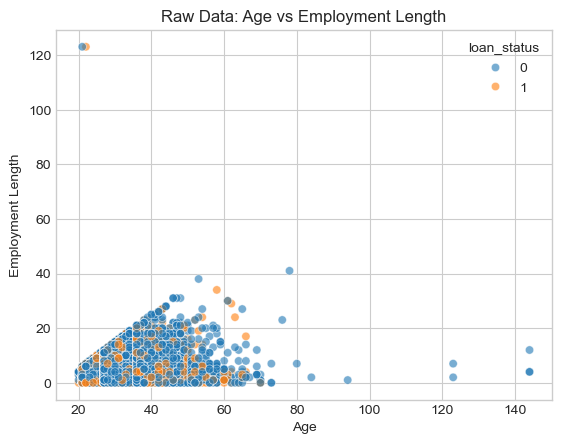

In [6]:
# Detect outliers with visuals
sns.scatterplot(data=cr_loan, x='person_age', y='person_emp_length', hue='loan_status', alpha=0.6)
plt.title('Raw Data: Age vs Employment Length')
plt.xlabel('Age')
plt.ylabel('Employment Length')
plt.show()

In [8]:
# Total number of null values per column
null_columns = cr_loan.columns[cr_loan.isnull().any()]
print(cr_loan[null_columns].isnull().sum())

person_emp_length     895
loan_int_rate        3116
dtype: int64


In [10]:
# Remove impossible outliers
# (age > 100) & (employment lengths > 60 years)
indices = cr_loan[(cr_loan['person_age'] > 100) | (cr_loan['person_emp_length'] > 60)].index
cr_loan.drop(indices, inplace=True)

# Fill missing values
# Impute missing interest rates with the mean
cr_loan['loan_int_rate'] = cr_loan['loan_int_rate'].fillna(cr_loan['loan_int_rate'].mean())

# Impute missing employment length with the median, considering its right-skewed distribution due to outliers
cr_loan['person_emp_length'] = cr_loan['person_emp_length'].fillna(cr_loan['person_emp_length'].median())

print('Clean data shape:', cr_loan.shape)
print("Sample data (Formatted table):")
display(cr_loan.head())

Clean data shape: (32574, 12)
Sample data (Formatted table):


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [12]:
# Convert categorical data into a binary (0 or 1) vector format so that the model can read them
print(cr_loan.info())

# For this, seperate numeric and categorical columns
cred_num = cr_loan.select_dtypes(exclude=['object'])
cred_cat = cr_loan.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns only
cred_cat_onehot = pd.get_dummies(cred_cat, dtype=int)

# Union the numeric columns with the one-hot encoded columns
cr_loan_encoded = pd.concat([cred_num, cred_cat_onehot], axis=1)

print(cr_loan_encoded.head())

<class 'pandas.core.frame.DataFrame'>
Index: 32574 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  object 
 3   person_emp_length           32574 non-null  float64
 4   loan_intent                 32574 non-null  object 
 5   loan_grade                  32574 non-null  object 
 6   loan_amnt                   32574 non-null  int64  
 7   loan_int_rate               32574 non-null  float64
 8   loan_status                 32574 non-null  int64  
 9   loan_percent_income         32574 non-null  float64
 10  cb_person_default_on_file   32574 non-null  object 
 11  cb_person_cred_hist_length  32574 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB
None
   person_age  person_income  p

In [14]:
# Separate the data into training(X) and test(y) sets
X = cr_loan_encoded.drop('loan_status', axis=1)
y = cr_loan_encoded['loan_status']

# Train-Test split, using test(y) set as the class labels to keep the original default ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

print('Training data shape:', X_train.shape)
print('Test data shape:', X_test.shape)
display(X_train.head())

Training data shape: (22801, 26)
Test data shape: (9773, 26)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
16684,23,44000,0.0,5500,6.17,0.13,4,1,0,0,...,1,1,0,0,0,0,0,0,1,0
617,25,50950,5.0,20000,11.48,0.39,3,0,0,0,...,0,0,1,0,0,0,0,0,1,0
21924,35,88020,6.0,6000,15.37,0.07,8,0,0,0,...,0,0,0,0,1,0,0,0,0,1
16869,22,34560,2.0,1200,19.29,0.03,2,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2330,22,31500,3.0,4500,9.88,0.14,2,1,0,0,...,1,0,1,0,0,0,0,0,1,0


In [16]:
# Initialise the scaler
# To avoid the convergence warning due to the high variance in some data (e.g., income vs interest rate)
# Scaling the data allows the model to converge by having a mean of 0 and a std of 1
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train)  # learn the mean and std of the training data and then scale it
X_test_scaled = scaler.transform(X_test)  # to scale the test data using the mean and std learned from the training data

# Initialise a logistic regression model and use the method .fit() to train
# solver='lbfgs' as the standard engine
# max_iter as the maximum number of iterations taken for the solvers to converge
clf_log = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=123)
clf_log.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [18]:
# Predict probabilities of default (PD, 0.0-1.0) for the ROC-AUC score
preds_probs = clf_log.predict_proba(X_test_scaled)

# Predit labels (0/1) for the classification report, based on the threshold of 0.5
preds_default = pd.DataFrame(preds_probs[:,1], columns=['prob_default'])
preds_default['loan_status'] = preds_default['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

print(preds_default.head())

   prob_default  loan_status
0      0.024832            0
1      0.864063            1
2      0.136663            0
3      0.165152            0
4      0.079033            0


Logistic Regression Performance:
              precision    recall  f1-score   support

 Non-Default       0.89      0.96      0.92      7641
     Default       0.78      0.55      0.65      2132

    accuracy                           0.87      9773
   macro avg       0.83      0.76      0.78      9773
weighted avg       0.86      0.87      0.86      9773

Logistic Regression ROC-AUC Score:
0.7557795557343089


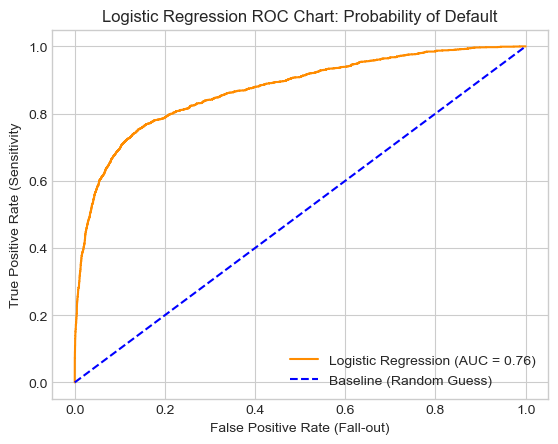

In [20]:
# Classification report:
# To compare the test data with the threshold labels
target_names = ['Non-Default', 'Default']
print('Logistic Regression Performance:')
print(classification_report(y_test, preds_default['loan_status'], target_names=target_names))

# ROC-AUC score:
# Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores
# To measure the model's ability to distinguish between classes, using the probabilities predicted
print('Logistic Regression ROC-AUC Score:')
print(roc_auc_score(y_test, preds_default['loan_status']))

# ROC curve: 
# Receiver Operating Characterstic
# To plot true positive rate (sensitivity) against false positive rate (fall-out)
fallout, sensitivity, thresholds = roc_curve(y_test, preds_default['prob_default'])
plt.plot(fallout, sensitivity, color='darkorange', label=f'Logistic Regression (AUC = {roc_auc_score(y_test, preds_default['loan_status']):.2f})')

# Add the baseline (diagonal dashed line)
plt.plot([0,1], [0,1], color='blue', linestyle='--', label='Baseline (Random Guess)')

plt.title('Logistic Regression ROC Chart: Probability of Default')
plt.xlabel('False Positive Rate (Fall-out)')
plt.ylabel('True Positive Rate (Sensitivity')
plt.legend(loc='lower right')
plt.show()

In [22]:
# Create a summary table of the coefficients
# To extract and interpret log-odds coefficients to identify primary risk drivers
# For this, flip the array of horizontal coefficients to match the column names of X vertically
log_coef = pd.DataFrame(clf_log.coef_.T, columns=['Coefficient'], index=X.columns)

# Sort the ressult to see the most influential risk drivers at the top
display(log_coef.sort_values(by='Coefficient', ascending=False))

,Coefficient
loan_percent_income,1.403470
loan_grade_D,0.600166
loan_grade_E,0.364697
person_home_ownership_RENT,0.342408
loan_grade_G,0.272413
loan_grade_F,0.184795
loan_intent_DEBTCONSOLIDATION,0.179934
loan_intent_HOMEIMPROVEMENT,0.173421
loan_int_rate,0.172983
loan_intent_MEDICAL,0.118895


In [24]:
# Combine training features and labels to filter by status
X_y_train = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)],
                      axis=1)

# Separate the class
nondefaults = X_y_train[X_y_train['loan_status'] == 0]
defaults = X_y_train[X_y_train['loan_status'] == 1]

# Undersampling non-defaults to match the number of defaults
# To fix the Logistic Regression issue above due to the imbalanced credit data
# This creates a balanced 50/50 training set
nondefaults_under = nondefaults.sample(len(defaults), random_state=123)

# Concatenate back into the final training set
X_y_train_under = pd.concat([nondefaults_under, defaults])
X_train_under = X_y_train_under.drop('loan_status', axis=1)
y_train_under = X_y_train_under['loan_status']

print(f'New training set ratio: {y_train_under.value_counts(normalize=True)}')

New training set ratio: loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64


In [28]:
# Initialise a gradient boosted tree model and use the method .fit() to train
# Use the same random_state=123 for consistency across the project
clf_gbt = xgb.XGBClassifier(random_state=123)
clf_gbt.fit(X_train_under, y_train_under)

# Predict probabilities of default (PD, 0.0-1.0) for the ROC-AUC score
gbt_preds_probs = clf_gbt.predict_proba(X_test)[:,1]

# Predict labels (0/1) for the classification report, based on the default threshold of 0.5
gbt_preds_default = clf_gbt.predict(X_test)

<Figure size 1600x800 with 0 Axes>

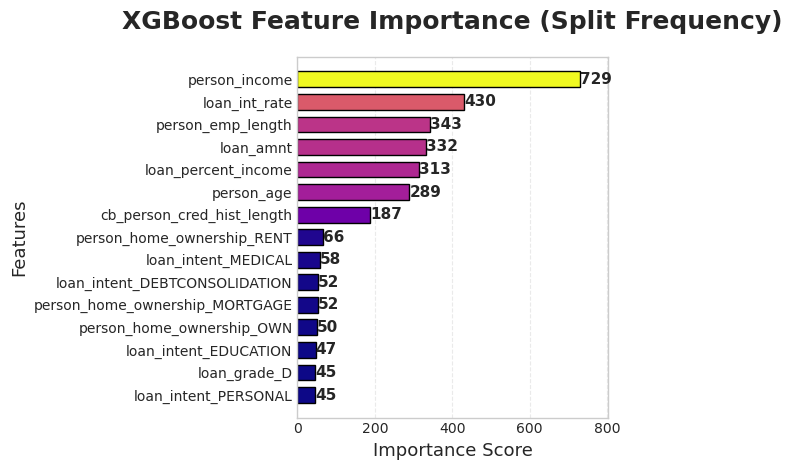


Top Important Features:

person_income             729.0
loan_int_rate             430.0
person_emp_length         343.0
loan_amnt                 332.0
loan_percent_income       313.0
person_age                289.0
cb_person_cred_hist_length 187.0
person_home_ownership_RENT 66.0
loan_intent_MEDICAL       58.0
person_home_ownership_MORTGAGE 52.0
loan_intent_DEBTCONSOLIDATION 52.0
person_home_ownership_OWN 50.0
loan_intent_EDUCATION     47.0
loan_intent_PERSONAL      45.0
loan_grade_D              45.0


In [54]:
# Plot the importance
# 'weight' counts how many times a feature was used to split data
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.figure(figsize=(16, 8))

ax = xgb.plot_importance(
    clf_gbt,
    importance_type='weight',
    max_num_features=15,
    height=0.7,
    grid=False,
    show_values=False
)

bars = ax.patches
values = [bar.get_width() for bar in bars]
norm = plt.Normalize(min(values), max(values))
colors = plt.cm.plasma(norm(values))

for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_edgecolor('black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center',
            fontsize=11,
            weight='bold')

ax.set_title('XGBoost Feature Importance (Split Frequency)', fontsize=18, weight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=13)
ax.set_ylabel('Features', fontsize=13)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

importance_scores = clf_gbt.get_booster().get_score(importance_type='weight')

importance_scores = dict(sorted(importance_scores.items(), key=lambda x: x[1], reverse=True))

print("\nTop Important Features:\n")
for k, v in list(importance_scores.items())[:15]:
    print(f"{k:<25} {v}")


XGBoost Performance:
              precision    recall  f1-score   support

 Non-Default       0.95      0.91      0.93      7641
     Default       0.72      0.83      0.77      2132

    accuracy                           0.89      9773
   macro avg       0.84      0.87      0.85      9773
weighted avg       0.90      0.89      0.90      9773

XGBoost ROC-AUC Score:
0.9481390570225354


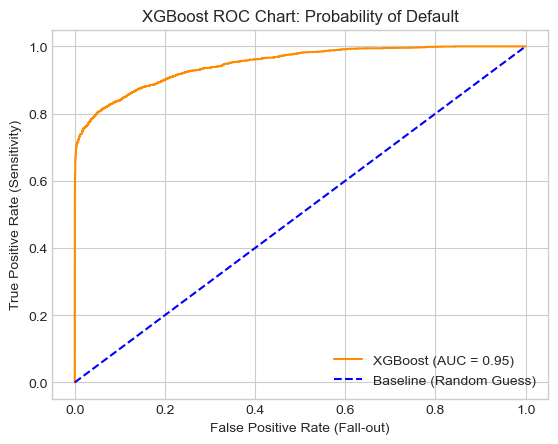

In [32]:
# Classification report:
# To compare the test data with the threshold labels
print('XGBoost Performance:')
print(classification_report(y_test, gbt_preds_default, target_names=target_names))

# ROC-AUC score:
# Area Under the Receiver Operating Characteristic Curve (ROC-AUC) from prediction scores
# To measure the model's ability to distinguish between classes, using the probabilities predicted
print('XGBoost ROC-AUC Score:')
print(roc_auc_score(y_test, gbt_preds_probs))

# ROC curve:
# Receiver Operating Characteristic
# To plot true positive rate (sensitivity) against false positive rate (fall-out)
fallout, sensitivity, thresholds = roc_curve(y_test, gbt_preds_probs)
plt.plot(fallout, sensitivity, color='darkorange', label=f'XGBoost (AUC = {roc_auc_score(y_test, gbt_preds_probs):.2f})')

# Add the baseline (diagonal dashed line)
plt.plot([0,1], [0,1], color='blue', linestyle='--', label='Baseline (Random Guess)')

plt.title('XGBoost ROC Chart: Probability of Default')
plt.xlabel('False Positive Rate (Fall-out)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.show()

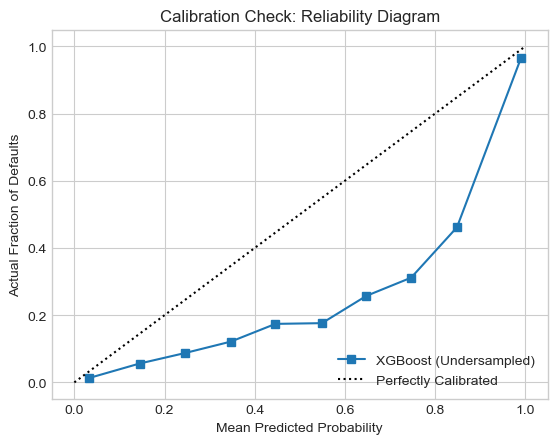

In [34]:
## Due to undersampling the training data to be 50/50, defaults happen more frequently in the model than the real world
## As a result, the probability of default (0.95) might be over-confident
## Therefore, through calibration we will ensure the predicted probability equals the actual frequency

# Calculate the calibration curve data 
# To show the percentage of true defaults for each predicted probability
# fraction_of_positives: Actual default rate in each bin
# mean_predicted_value: The average probability the model predicted for that bin
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, gbt_preds_probs, n_bins=10)

# Plot the reliability diagram
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='XGBoost (Undersampled)')
plt.plot([0,1], [0,1], 'k:', label='Perfectly Calibrated')  # The diagonal reference

plt.title('Calibration Check: Reliability Diagram')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Fraction of Defaults')
plt.legend(loc='lower right')
plt.show()

In [36]:
# Here, we create a DataFrame that combines our predictions with the actual outcomes to simulate different business rules

# Create a strategy DataFrame
strat_df = pd.DataFrame(gbt_preds_probs, columns=['prob_default'])
print(strat_df.head())

# Add the actual status from the test set
strat_df['loan_status'] = y_test.reset_index(drop=True)

# Create a column for the "Decision" based on a test threshold (e.g., 0.2 PD to be safe)
strat_df['financial_decision'] = strat_df['prob_default'].apply(lambda x : 1 if x > 0.2 else 0)

display(strat_df.head())

   prob_default
0      0.241775
1      0.998715
2      0.074677
3      0.155311
4      0.030843


,prob_default,loan_status,financial_decision
0,0.241775,0,1
1,0.998715,1,1
2,0.074677,0,0
3,0.155311,0,0
4,0.030843,0,0


In [38]:
# Let's automate the calculation for multiple thresholds

# For this, calculate two critical metrics for different "Acceptance Rates", percentage of new loans are accepted
# Bad Rate: The percentage of accepted loans that actually defaulted (risk)
# Estimated Portfolio Value: A simplified calculation of potential profit

# Define the range of acceptance rates to test
accept_rates = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Create empty lists to store the results
thresholds = []
bad_rates = []

# Loop through rates to find the required thresholds
for rate in accept_rates:
    # Find the probability threshold for this acceptance rate
    thresh = np.quantile(strat_df['prob_default'], rate)
    thresholds.append(thresh)

    # Create accepted loans and calculate the bad rate for this threshold
    # Here, Bad Rate = Accepted Defaults / Total Accepted Loans
    accepted_loans = strat_df[strat_df['prob_default'] <= thresh]
    bad_rate = len(accepted_loans[accepted_loans['loan_status'] == 1]) / len(accepted_loans)
    bad_rates.append(bad_rate)

# Create the strategy table
strategy_table = pd.DataFrame({
    'Acceptance Rate': accept_rates,
    'Threshold': thresholds,
    'Bad Rate': bad_rates
})

# Calculate estimated portfolio value
# Assume average loan is €10,000
# Here, Projected Profit = Accepted Loans * (Average Loan * Interest Rate) * (1 - Bad Rate)
#                        - Accepted Loans * (Average Loan * Loss Rate) * Bad Rate
avg_loan_amnt = 10000
interest_rate = 0.15  # The bank earns 15% on successful loans
loss_rate = 1.0  # The bank loses 100% of the principal on defaults

strategy_table['Projected Profit'] = (
    (strategy_table['Acceptance Rate'] * len(strat_df)) * (avg_loan_amnt * interest_rate) * (1 - strategy_table['Bad Rate'])
     - ((strategy_table['Acceptance Rate'] * len(strat_df)) * (avg_loan_amnt * loss_rate) * strategy_table['Bad Rate'])
)

display(strategy_table)

,Acceptance Rate,Threshold,Bad Rate,Projected Profit
0,1.0,0.999998,0.218152,-9.858500e+06
1,0.9,0.995330,0.131325,-9.000716e+04
2,0.8,0.700425,0.058966,6.425829e+06
3,0.7,0.392174,0.039760,7.133604e+06
4,0.6,0.244855,0.026944,6.978762e+06
5,0.5,0.152463,0.018621,6.283357e+06
6,0.4,0.094722,0.011256,5.357774e+06
7,0.3,0.053045,0.005116,4.225356e+06
8,0.2,0.021019,0.004092,2.839919e+06
9,0.1,0.003892,0.000000,1.465950e+06


In [40]:
# Find the best balance in our conclusion
best_strategy = strategy_table.sort_values(by='Projected Profit', ascending=False).iloc[0]
print('The Best Strategy:\n', best_strategy, sep='')

# Format the numbers
acc_rate = f'{best_strategy['Acceptance Rate'] * 100:,.0f}%'
bad_rate = f'{best_strategy['Bad Rate'] * 100:,.2f}%'
est_net_profit = f'€{best_strategy['Projected Profit']:,.0f}'

print('Acceptance Rate of the Best Strategy:', acc_rate)
print('Bad Rate of the Best Strategy:', bad_rate)
print('Estimated Net Profit of the Best Strategy:', est_net_profit)

The Best Strategy:
Acceptance Rate     7.000000e-01
Threshold           3.921745e-01
Bad Rate            3.976027e-02
Projected Profit    7.133604e+06
Name: 3, dtype: float64
Acceptance Rate of the Best Strategy: 70%
Bad Rate of the Best Strategy: 3.98%
Estimated Net Profit of the Best Strategy: €7,133,604
